In [1]:
from colorama import Fore
from IPython.display import display, Math

from astropy.io import fits
from scipy.io import readsav
from scipy.stats import gaussian_kde
from scipy import stats as ss
import numpy as np
import pandas as pd
import os
import copy

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tools as t

In [2]:
# load TS1
path_data = '../data/sim_series/'  # directory where the files are saved
data_spectra = fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie0.fits')
data_spectra = np.array(data_spectra)

times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days, same for all time series

In [3]:
# Parameters

N = 3686  # timesteps
M = 20  # PCs
TS = 1

# Load data

X = []
y = []

for i in range(N):

    data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')

    X.append(data['scores'].float())
    y.append(torch.as_tensor(data['rv'], dtype=torch.float32))

X = torch.stack(X)
y = torch.stack(y).reshape(-1, 1)

print("Total X shape:", X.shape)
print("Total y shape:", y.shape)

/tmp/ipykernel_4024950/2577428456.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')


Total X shape: torch.Size([3686, 20])
Total y shape: torch.Size([3686, 1])


In [4]:
# RV stats
print(f'Mean: {y.mean().item()}')
print(f'Sigma: {y.std().item()}')
print(f'Min: {y.min().item()}')
print(f'Max: {y.max().item()}')

Mean: -3.8809319646837537e-10
Sigma: 0.9465776681900024
Min: -3.7014224529266357
Max: 3.3682401180267334


In [5]:
batch_size = 32

# Chronological train/test split

train_size = int(0.7 * N)
val_size = int(0.1 * N)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

#print(X_train.mean(dim=0))
#print(X_train.std(dim=0))

#print(((X_train - X_train.mean(dim=0)) / X_train.std(dim=0)).std(dim=0))

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)

print("Validation X shape:", X_val.shape)
print("Validation y shape:", y_val.shape)

print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

# Scaling scores
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.numpy())
X_val_scaled = scaler.transform(X_val.numpy())
X_test_scaled = scaler.transform(X_test.numpy())

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

# Create Datasets
# Pair the rows of X with the corresponding rows of y

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Create DataLoaders
# takes a Dataset and gives samples to the model in batches

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # The model sees the same 80% of the data, but in a different order each epoch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False  # There's no benefit to shuffling it because we're not updating the model during testing
)

Train X shape: torch.Size([2580, 20])
Train y shape: torch.Size([2580, 1])
Validation X shape: torch.Size([368, 20])
Validation y shape: torch.Size([368, 1])
Test X shape: torch.Size([738, 20])
Test y shape: torch.Size([738, 1])


In [6]:
# Function to evaluate a dataset
def evaluate_model(data_loader):

    model.eval()
    
    all_predictions = []
    all_targets = []
    all_loss = []
    sample_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            y_pred = model(X_batch)

            all_predictions.append(y_pred)
            all_targets.append(y_batch)

            loss = criterion(y_pred, y_batch)
            sample_loss += loss.item()
    sample_loss /= len(data_loader)
    # Combine all batches
    y_pred = torch.cat(all_predictions).squeeze().numpy()
    y_true = torch.cat(all_targets).squeeze().numpy()

    # Metrics
    #mse = np.mean((y_pred - y_true) ** 2)
    #mae = np.mean(np.abs(y_pred - y_true))
    #rmse = np.sqrt(mse)
    #r2 = r2_score(y_true, y_pred)

    return y_true, y_pred, y_true-y_pred, sample_loss

In [7]:
# bilinear model
class BilinearModel(nn.Module):
    def __init__(self, M):
        super().__init__()

        # First hidden layers
        self.hidden = nn.Sequential(
            nn.Linear(M, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )

        # Bilinear interaction:
        # input 1 = original 20 PCs
        # input 2 = 16-dimensional hidden representation
        # output  = 16-dimensional representation
        self.bilinear = nn.Bilinear(M, 16, 16)

        # Final regression layer
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        # Hidden representation
        h = self.hidden(x)

        # Bilinear interaction between original PCs and hidden features
        h = self.bilinear(x, h)

        # RV prediction
        y = self.output(h)

        return y

In [8]:
# Model
# M = 20 PCs
model = nn.Sequential(
    nn.Linear(M, 32),
    #nn.BatchNorm1d(32),
    nn.ReLU(),

    nn.Linear(32, 16),
    #nn.BatchNorm1d(16),
    nn.ReLU(),

    nn.Linear(16, 1),
)


#model = BilinearModel(M)

# Loss and optimizer
criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0
)

# Scheduler: if validation loss stops improving, PyTorch reduces the learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=20
)

# Early stopping parameters
patience = 50
best_val_loss = float("inf")
epochs_without_improvement = 0

# Store the parameters of the best model
best_model_state = copy.deepcopy(model.state_dict())

# Training
epochs = 1000
model_history = {
    'y_train_true': [],
    'y_train_pred': [],
    'diff_train': [],
    'loss_train': [],
    'y_val_true': [],
    'y_val_pred': [],
    'diff_val': [],
    'loss_val': [],
    'y_test_true': [],
    'y_test_pred': [],
    'diff_test': [],
    'loss_test': [],
}
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Average loss over batches
    train_loss /= len(train_loader)

    # Evaluate all sets
    y_tr_true, y_tr_pred, diff_tr, loss_tr = evaluate_model(train_loader)
    y_va_true, y_va_pred, diff_va, loss_va = evaluate_model(val_loader)
    y_te_true, y_te_pred, diff_te, loss_te = evaluate_model(test_loader)

    # Save evaluation
    model_history['y_train_true'].append(y_tr_true)
    model_history['y_train_pred'].append(y_tr_pred)
    model_history['diff_train'].append(diff_tr)
    model_history['loss_train'].append(loss_tr)

    model_history['y_val_true'].append(y_va_true)
    model_history['y_val_pred'].append(y_va_pred)
    model_history['diff_val'].append(diff_va)
    model_history['loss_val'].append(loss_va)

    model_history['y_test_true'].append(y_te_true)
    model_history['y_test_pred'].append(y_te_pred)
    model_history['diff_test'].append(diff_te)
    model_history['loss_test'].append(loss_te)

    # Early stopping
    if loss_va < best_val_loss:
        # Validation loss improved
        best_val_loss = loss_va
        epochs_without_improvement = 0
        # Save best model
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        # No improvement
        epochs_without_improvement += 1

    # Print progress
    if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"train loss = {train_loss:.4f}, "
            f"val loss = {loss_va:.4f}"
        )

    # Stop if validation loss hasn't improved
    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping at epoch {epoch}. "
        )
        break

    # Scheduler
    scheduler.step(loss_va)
    
# Restore best model
model.load_state_dict(best_model_state)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 0: train loss = 0.7543, val loss = 0.6879
Epoch 100: train loss = 0.1267, val loss = 0.1449

Early stopping at epoch 182. 
Best validation loss: 0.1424


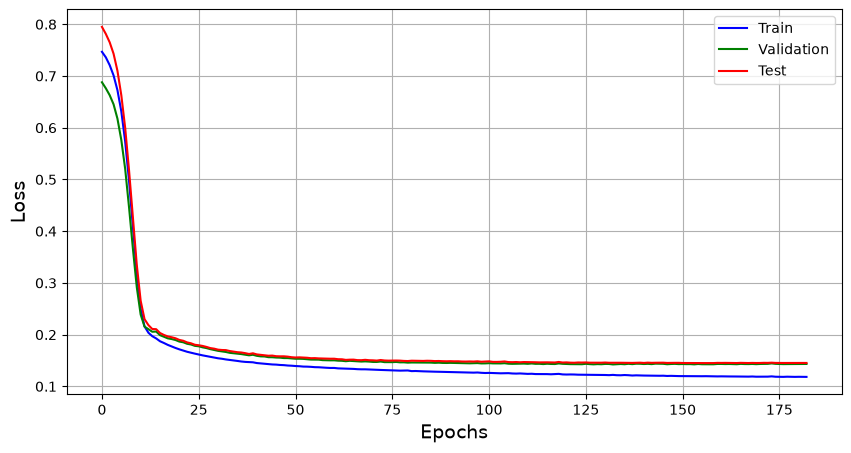

In [9]:
# plot loss history

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()

ax.plot(model_history['loss_train'], color='blue', label='Train')
ax.plot(model_history['loss_val'], color='green', label='Validation')
ax.plot(model_history['loss_test'], color='red', label='Test')

ax.set_xlabel('Epochs', size=14)
ax.set_ylabel('Loss', size=14)
#ax.set_yscale('log')
ax.legend()

plt.show()

In [10]:
# Evaluating the best model
model.eval()

# Evaluate training set
y_train_true, y_train_pred, diff_train, loss_train = evaluate_model(train_loader)

# Evaluate validation set
y_val_true, y_val_pred, diff_val, loss_val = evaluate_model(val_loader)

# Evaluate testing set
y_test_true, y_test_pred, diff_test, loss_test = evaluate_model(test_loader)

# Print results
print('---------- Best model results ----------')
print(f'Train loss: {loss_train:.4f}')
print(f'Validation loss: {loss_val:.4f}')
print(f'Test loss: {loss_test:.4f}')

---------- Best model results ----------
Train loss: 0.1221
Validation loss: 0.1424
Test loss: 0.1457


In [45]:
def plot_true_vs_pred(true, pred, ax, color):
    ax.scatter(true, pred, alpha=0.6, label='Model results', color=color)

    # Perfect-prediction line
    min_val = min(true.min(), pred.min())
    max_val = max(true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--', color='k', label='Ideal case')

    ax.set_xlabel('True RV [m/s]', size=13)
    ax.set_ylabel('Predicted RV [m/s]', size=13)
    ax.grid(True)
    #ax.axis('equal')
    ax.legend()

Standard deviation of the predicted train RVs: 0.928
Standard deviation of the train RVs: 0.941

Standard deviation of the predicted validation RVs: 0.752
Standard deviation of the validation RVs: 0.781

Standard deviation of the predicted test RVs: 0.950
Standard deviation of the test RVs: 0.977



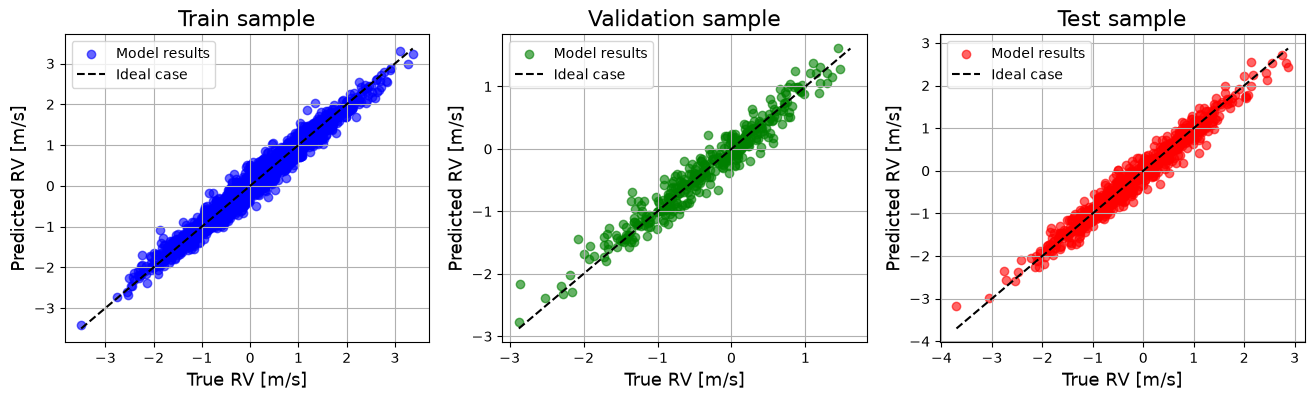

In [46]:
# plot true vs predicted for each sample
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

plot_true_vs_pred(y_train_true, y_train_pred, axs[0], 'blue')
plot_true_vs_pred(y_val_true, y_val_pred, axs[1], 'green')
plot_true_vs_pred(y_test_true, y_test_pred, axs[2], 'red')

axs[0].set_title('Train sample', size=16)
axs[1].set_title('Validation sample', size=16)
axs[2].set_title('Test sample', size=16)

print(Fore.BLUE + f'Standard deviation of the predicted train RVs: {y_train_pred.std():.3f}')
print(Fore.BLUE + f'Standard deviation of the train RVs: {y_train.std():.3f}\n')

print(Fore.GREEN + f'Standard deviation of the predicted validation RVs: {y_val_pred.std():.3f}')
print(Fore.GREEN + f'Standard deviation of the validation RVs: {y_val.std():.3f}\n')

print(Fore.RED + f'Standard deviation of the predicted test RVs: {y_test_pred.std():.3f}')
print(Fore.RED + f'Standard deviation of the test RVs: {y_test.std():.3f}\n')

In [47]:
# arange data to superpose the plots above
data_train = {
    'y_train_true': y_train_true,
    'y_train_pred': y_train_pred,
}

data_val = {
    'y_val_true': y_val_true,
    'y_val_pred': y_val_pred,
}

data_test = {
    'y_test_true': y_test_true,
    'y_test_pred': y_test_pred
}

df_train = pd.DataFrame(data=data_train)
df_val = pd.DataFrame(data=data_val)
df_test = pd.DataFrame(data=data_test)

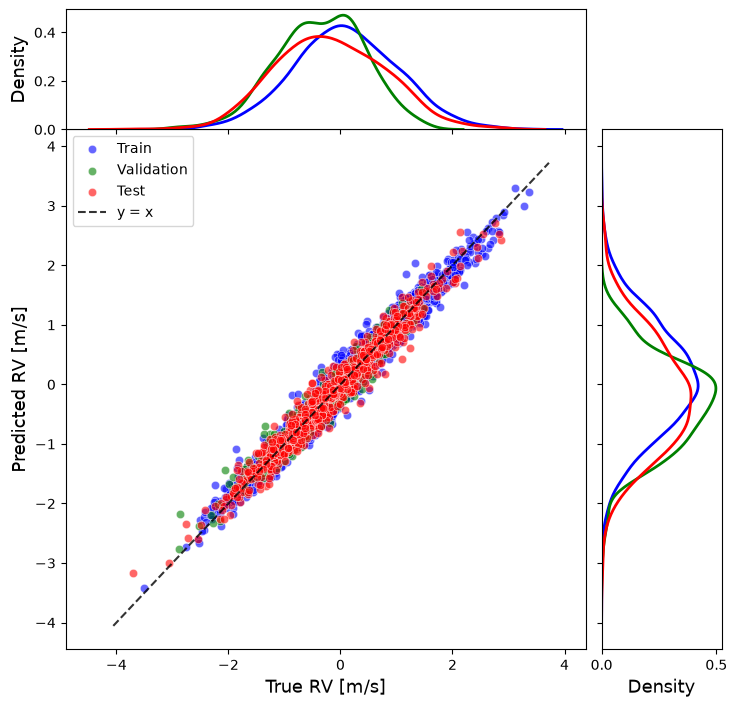

In [48]:
# Superposed with histograms

fig = plt.figure(figsize=(8, 8))

# Main scatter plot
ax = fig.add_axes([0.12, 0.12, 0.65, 0.65])

sns.scatterplot(
    data=df_train,
    x='y_train_true',
    y='y_train_pred',
    color='blue',
    alpha=.6,
    label='Train',
    ax=ax
)

sns.scatterplot(
    data=df_val,
    x='y_val_true',
    y='y_val_pred',
    color='green',
    alpha=.6,
    label='Validation',
    ax=ax
)

sns.scatterplot(
    data=df_test,
    x='y_test_true',
    y='y_test_pred',
    color='red',
    alpha=.6,
    label='Test',
    ax=ax
)

# Reference line y = x
lims = ax.get_xlim()
ax.plot(lims, lims, '--', color='black', alpha=0.8, label='y = x')

ax.set_xlabel('True RV [m/s]', size=13)
ax.set_ylabel('Predicted RV [m/s]', size=13)
ax.legend()


# ---- Smooth marginal distributions ----

# Top: distributions of TRUE values
ax_top = fig.add_axes([0.12, 0.77, 0.65, 0.15], sharex=ax)

sns.kdeplot(
    data=df_train,
    x='y_train_true',
    color='blue',
    linewidth=2,
    ax=ax_top,
    label='Train'
)

sns.kdeplot(
    data=df_val,
    x='y_val_true',
    color='green',
    linewidth=2,
    ax=ax_top,
    label='Validation'
)

sns.kdeplot(
    data=df_test,
    x='y_test_true',
    color='red',
    linewidth=2,
    ax=ax_top,
    label='Test'
)

ax_top.set_ylabel('Density', size=13)
ax_top.set_xlabel('')
ax_top.tick_params(axis='x', labelbottom=False)


# Right: distributions of PREDICTED values
ax_right = fig.add_axes([0.79, 0.12, 0.15, 0.65], sharey=ax)

sns.kdeplot(
    data=df_train,
    y='y_train_pred',
    color='blue',
    linewidth=2,
    ax=ax_right,
    label='Train'
)

sns.kdeplot(
    data=df_val,
    y='y_val_pred',
    color='green',
    linewidth=2,
    ax=ax_right,
    label='Validation'
)

sns.kdeplot(
    data=df_test,
    y='y_test_pred',
    color='red',
    linewidth=2,
    ax=ax_right,
    label='Test'
)

ax_right.set_xlabel('Density', size=13)
ax_right.set_ylabel('')
ax_right.tick_params(axis='y', labelleft=False)

plt.show()

In [49]:
# true - predicted for each sample
diff_train = y_train_true - y_train_pred
diff_val = y_val_true - y_val_pred
diff_test = y_test_true - y_test_pred

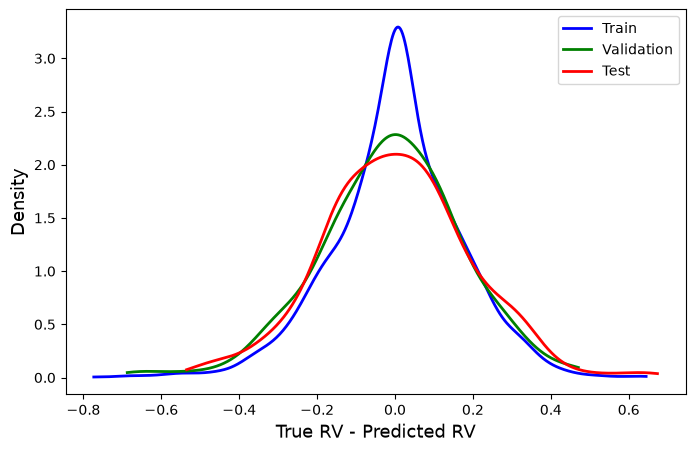

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

#ax.hist(diff_train, alpha=.5, density=True)
#ax.hist(diff_val, alpha=.5, density=True)
#ax.hist(diff_test, alpha=.5, density=True)

# Smooth KDE curve
# gaussian_kde: estimates the probability density function of a random variable
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html
kde_train = gaussian_kde(diff_train)
x_train = np.linspace(diff_train.min(), diff_train.max(), 500)

kde_val = gaussian_kde(diff_val)
x_val = np.linspace(diff_val.min(), diff_val.max(), 500)

kde_test = gaussian_kde(diff_test)
x_test = np.linspace(diff_test.min(), diff_test.max(), 500)

# Density histograms
ax.plot(x_train, kde_train(x_train), linewidth=2, color='blue', label='Train')
ax.plot(x_val, kde_val(x_val), linewidth=2, color='green', label='Validation')
ax.plot(x_test, kde_test(x_test), linewidth=2, color='red', label='Test')

ax.set_xlabel('True RV - Predicted RV', size=13)
ax.set_ylabel('Density', size=13)
ax.legend()

plt.show()

In [51]:
# compute means
mean_train = np.mean(diff_train)
mean_val = np.mean(diff_val)
mean_test = np.mean(diff_test)

# compute stds
std_train = np.std(diff_train)
std_val = np.std(diff_val)
std_test = np.std(diff_test)

std_total = np.std([std_train, std_val, std_test])

std_diff = (std_test - std_train) / std_total

In [52]:
print('---------- Mean of True-Predicted RV ----------')
print(f'Train: {mean_train:.5f}')
print(f'Validation: {mean_val:.5f}')
print(f'Test: {mean_test:.5f}')

print('---------- Std of True-Predicted RV ----------')
print(f'Train: {std_train:.4f}')
print(f'Validation: {std_val:.4f}')
print(f'Test: {std_test:.4f}')

print(f'\nSigma total = {std_total:.4f}\n')

display(Math(
    rf'\text{{Difference between }} \sigma_{{test}} \text{{ and }} '
    rf'\sigma_{{train}}: {std_diff:.1f}\sigma'
))

---------- Mean of True-Predicted RV ----------
Train: 0.00411
Validation: -0.01110
Test: 0.00188
---------- Std of True-Predicted RV ----------
Train: 0.1640
Validation: 0.1839
Test: 0.1899

Sigma total = 0.0111



<IPython.core.display.Math object>

In [53]:
# calculate std of True-Predicted (sigma) for each epoch

sigma_train = np.array(model_history['y_train_true']) - np.array(model_history['y_train_pred'])
sigma_val = np.array(model_history['y_val_true']) - np.array(model_history['y_val_pred'])
sigma_test = np.array(model_history['y_test_true']) - np.array(model_history['y_test_pred'])

sigma_train = np.std(sigma_train, axis=1)
sigma_val = np.std(sigma_val, axis=1)
sigma_test = np.std(sigma_test, axis=1)

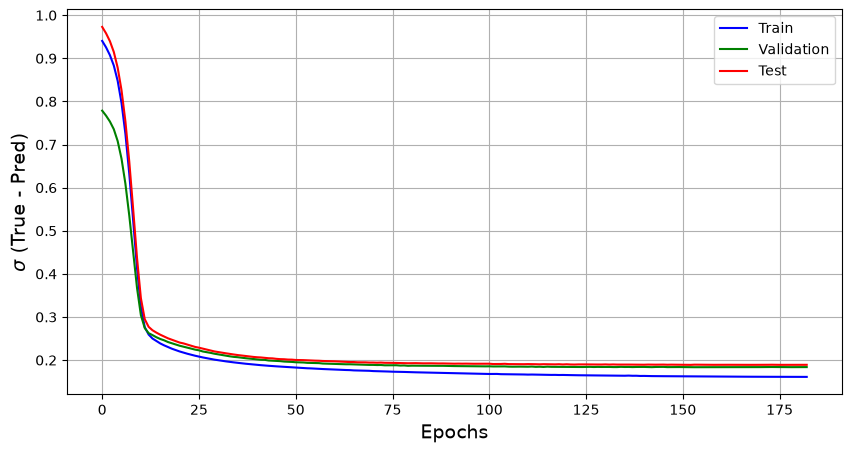

In [54]:
# plot sigma history

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()

ax.plot(sigma_train, color='blue', label='Train')
ax.plot(sigma_val, color='green', label='Validation')
ax.plot(sigma_test, color='red', label='Test')

ax.set_xlabel('Epochs', size=14)
ax.set_ylabel(r'$\sigma$ (True - Pred)', size=14)
ax.legend()
#ax.set_yscale('log')

plt.show()

In [55]:
# do a linear model (y = I * X) to compare with the result from the neural network
k = 20  # number of PCs used for the fit

scores_matrix = np.array(X)[:, :k]  # this is I in the fit, a matrix whose columns are the scores of the first k principal components

# separate the scores and RVs into sub samples
scores_train = np.array(X)[:train_size, :k]
scores_val   = np.array(X)[train_size:train_size + val_size, :k]
scores_test  = np.array(X)[train_size + val_size:, :k]

rv = np.squeeze(np.array(y))  # RV data in a 1-d array
rv_train = rv[:train_size]
rv_val   = rv[train_size:train_size + val_size]
rv_test  = rv[train_size + val_size:]

# training the linear model

G = np.dot(scores_train.T, scores_train)
b = np.dot(scores_train.T, rv_train)
alpha = np.linalg.solve(G, b)

/tmp/ipykernel_4024950/3835424315.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scores_matrix = np.array(X)[:, :k]  # this is I in the fit, a matrix whose columns are the scores of the first k principal components
/tmp/ipykernel_4024950/3835424315.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scores_train = np.array(X)[:train_size, :k]
/tmp/ipykernel_4024950/3835424315.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing c

In [56]:
# use alpha to predict the RVs
y_linear       = np.dot(alpha, scores_matrix.T)  # all predictions
y_train_linear = np.dot(alpha, scores_train.T)   # train predictions
y_val_linear   = np.dot(alpha, scores_val.T)     # validation predictions
y_test_linear  = np.dot(alpha, scores_test.T)    # test predictions

# calculate residuals
diff_all_linear   = rv - y_linear
diff_train_linear = rv_train - y_train_linear
diff_val_linear   = rv_val - y_val_linear
diff_test_linear  = rv_test - y_test_linear

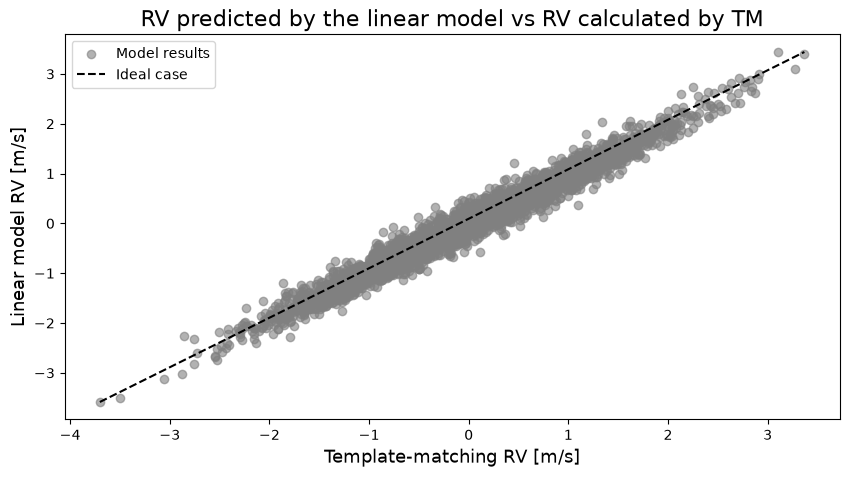

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('RV predicted by the linear model vs RV calculated by TM', size=16)

ax.scatter(rv, y_linear, color='gray', alpha=.6, label='Model results')
ax.plot([min(rv), max(rv)], [min(y_linear), max(y_linear)], linestyle='--', color='k', label='Ideal case')
ax.set_xlabel('Template-matching RV [m/s]', size=13)
ax.set_ylabel('Linear model RV [m/s]', size=13)
ax.legend()

plt.show()

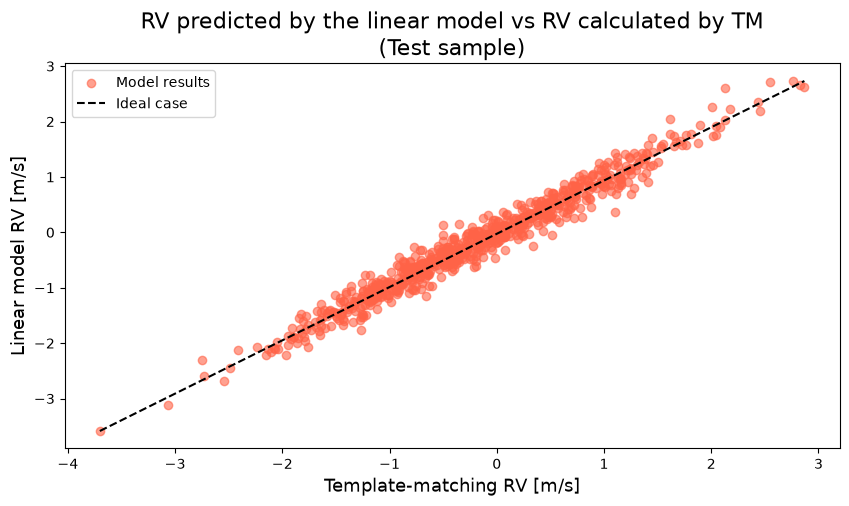

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('RV predicted by the linear model vs RV calculated by TM\n(Test sample)', size=16)

ax.scatter(rv_test, y_test_linear, color='tomato', alpha=.6, label='Model results')
ax.plot([min(rv_test), max(rv_test)], [min(y_test_linear), max(y_test_linear)], linestyle='--', color='k', label='Ideal case')
ax.set_xlabel('Template-matching RV [m/s]', size=13)
ax.set_ylabel('Linear model RV [m/s]', size=13)
ax.legend()

plt.show()

In [59]:
times_test = times[train_size + val_size:]

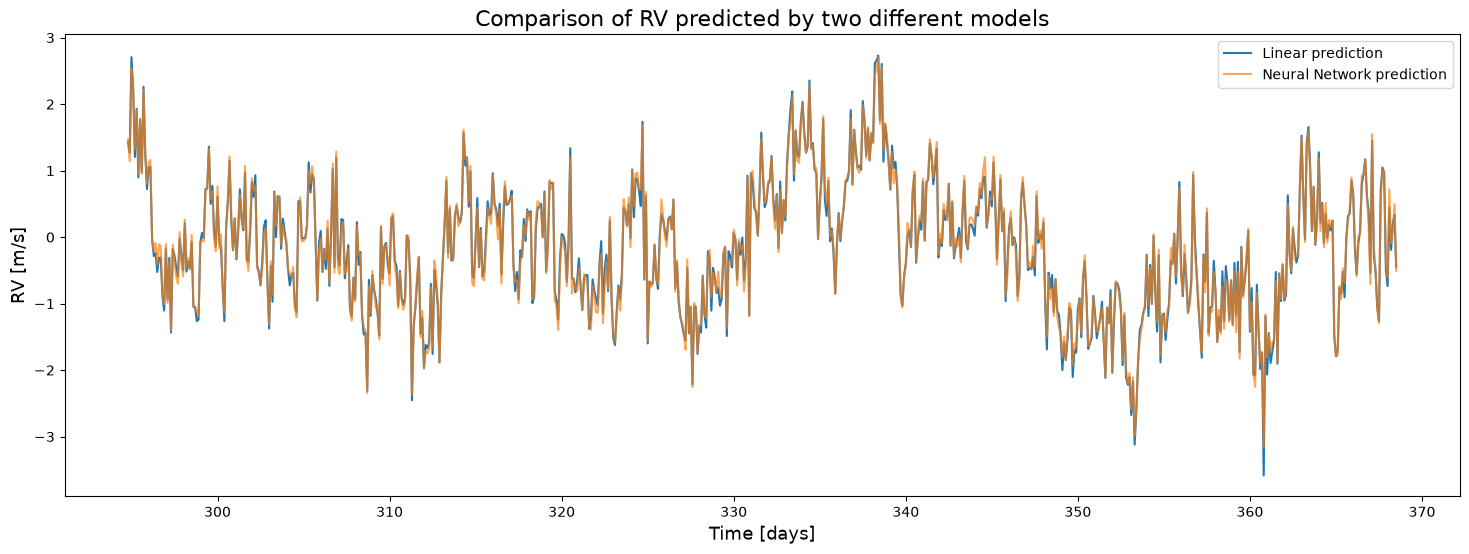

In [60]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.set_title('Comparison of RV predicted by two different models', size=16)

ax.plot(times_test, y_test_linear, label='Linear prediction')
ax.plot(times_test, y_test_pred, label='Neural Network prediction', alpha=.7)
#plt.plot(times_test, rv[train_size + val_size:])

ax.set_xlabel('Time [days]', size=13)
ax.set_ylabel('RV [m/s]', size=13)
ax.legend()

plt.show()

In [61]:
print('---------- Mean difference between True and predicted RVs ----------')
print(f'True RV - Linear prediction = {np.mean(y_test_true - y_test_linear):.3f} m/s')
print(f'True RV - Neural Network prediction = {np.mean(y_test_true - np.array(y_test_pred)):.3f} m/s')
print(f'Linear prediction - Neural Network prediction = {np.mean(y_test_linear - np.array(y_test_pred)):.3f} m/s')

print('---------- Standard deviation of the difference between True and predicted RVs ----------')
print(f'True RV - Linear prediction = {np.std(diff_test_linear):.2f} m/s')
print(f'True RV - Neural Network prediction = {std_test:.2f} m/s')
print(f'Linear prediction - Neural Network prediction = {np.std(y_test_linear - np.array(y_test_pred)):.2f} m/s')

---------- Mean difference between True and predicted RVs ----------
True RV - Linear prediction = 0.002 m/s
True RV - Neural Network prediction = 0.002 m/s
Linear prediction - Neural Network prediction = -0.000 m/s
---------- Standard deviation of the difference between True and predicted RVs ----------
True RV - Linear prediction = 0.18 m/s
True RV - Neural Network prediction = 0.19 m/s
Linear prediction - Neural Network prediction = 0.09 m/s


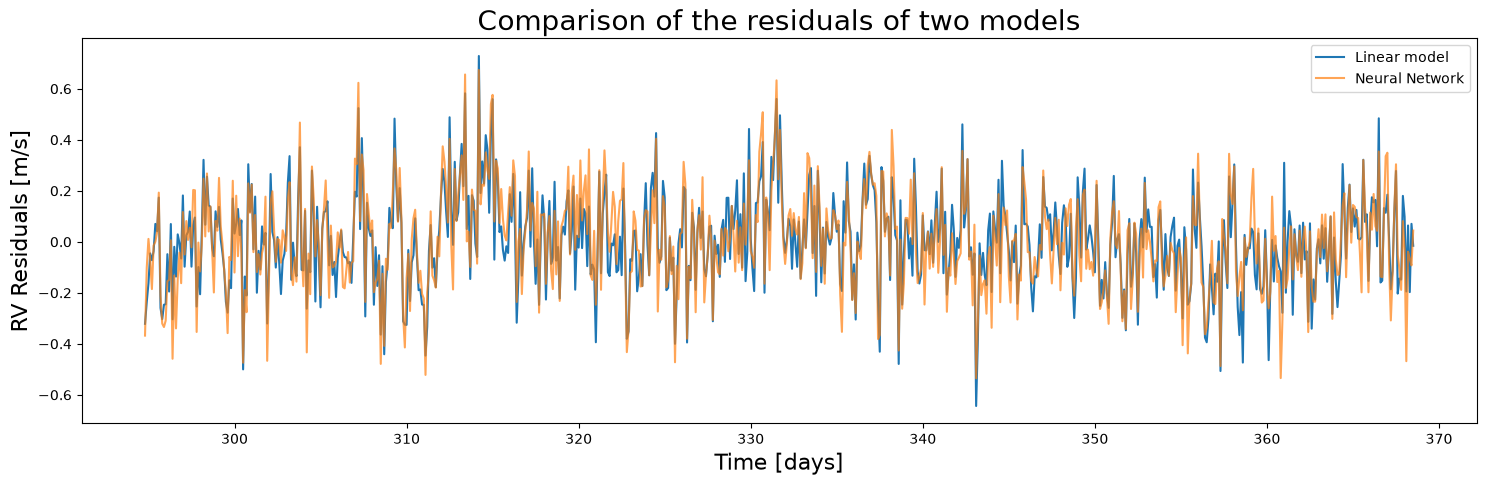

In [62]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_title('Comparison of the residuals of two models', size=20)

ax.plot(times_test, y_test_true - y_test_linear, label='Linear model')
ax.plot(times_test, diff_test, label='Neural Network', alpha=.7)

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('RV Residuals [m/s]', size=16)
ax.legend()

plt.show()

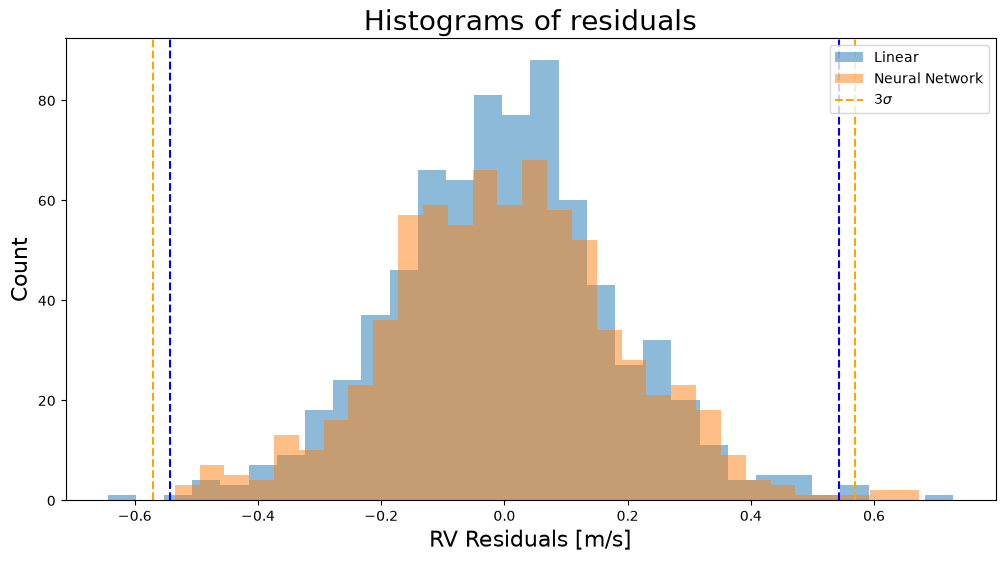

In [63]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('Histograms of residuals', size=20)

ax.hist(diff_test_linear, bins=30, alpha=0.5, label='Linear')
ax.hist(diff_test, bins=30, alpha=0.5, label='Neural Network')

# plot 1 sigma
#ax.axvline(np.std(diff_test_linear), color='blue')
#ax.axvline(-np.std(diff_test_linear), color='blue')
#ax.axvline(std_test, color='orange')
#ax.axvline(-std_test, color='orange')

# plot 3 sigma
ax.axvline(3 * np.std(diff_test_linear), color='blue', linestyle='--')
ax.axvline(-3 * np.std(diff_test_linear), color='blue', linestyle='--')
ax.axvline(3 * std_test, color='orange', linestyle='--')
ax.axvline(-3 * std_test, color='orange', linestyle='--', label=r'$3\sigma$')

ax.set_xlabel('RV Residuals [m/s]', size=16)
ax.set_ylabel('Count', size=16)
ax.legend()

plt.show()

In [64]:
# are PCs correlated with the residuals
diff_all = np.concatenate((diff_train, diff_val, diff_test))
corr_all = []

for i in range(M):
    scores_i = scores_matrix[:, i]
    corr = ss.pearsonr(diff_all, scores_i)[0]
    corr_all.append(corr)

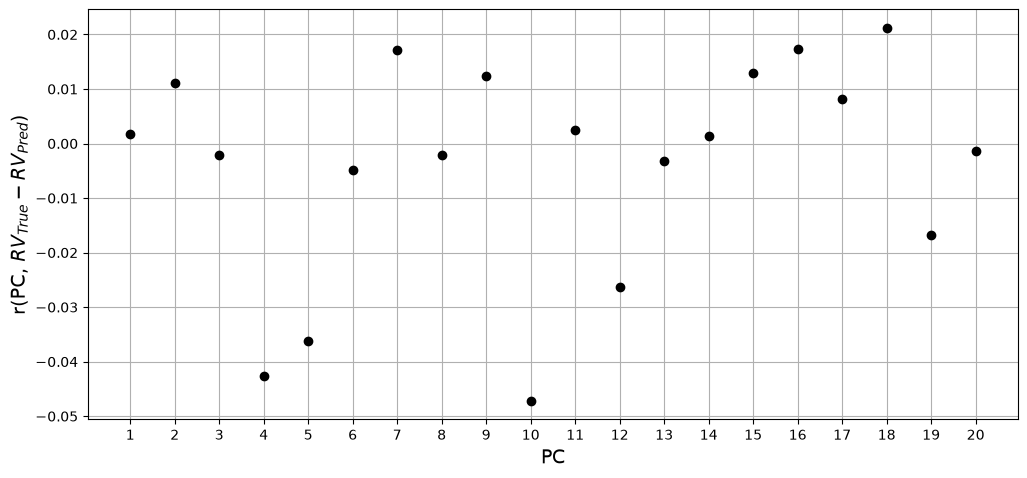

In [65]:
pc_arr = np.linspace(1, M, M)

fig, ax = plt.subplots(figsize=(12, 5))
ax.grid()

ax.scatter(pc_arr, corr_all, color='k', zorder=2)
ax.set_xlabel('PC', size=14)
ax.set_xticks(pc_arr)
ax.set_ylabel(r'r(PC, $RV_{True} - RV_{Pred}$)', size=14)

plt.subplots_adjust(top=.93)
plt.show()

In [103]:
# bootstrap
bs_li = ss.bootstrap((diff_test_linear, ), np.std, confidence_level=.95)
bs_nn = ss.bootstrap((diff_test, ), np.std, confidence_level=.95)

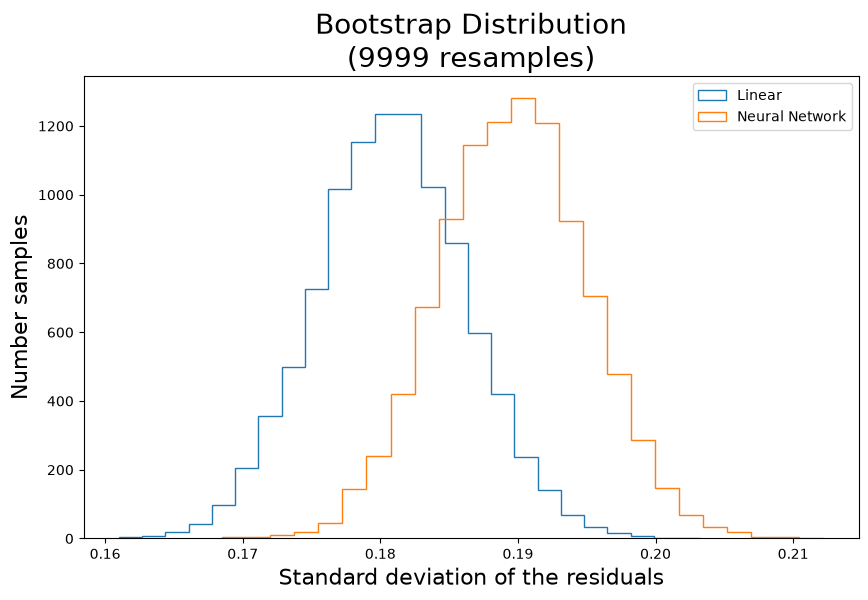

In [104]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(bs_li.bootstrap_distribution, bins=25, histtype='step', label='Linear')
ax.hist(bs_nn.bootstrap_distribution, bins=25, histtype='step', label='Neural Network')
ax.set_title('Bootstrap Distribution\n(9999 resamples)', size=20)
ax.set_xlabel('Standard deviation of the residuals', size=16)
ax.set_ylabel('Number samples', size=16)
ax.legend()

plt.show()

In [109]:
# do bootstrap of the difference between the two models
diff_li_nn = y_test_linear - y_test_pred
bs_diff = ss.bootstrap((diff_li_nn, ), np.mean)

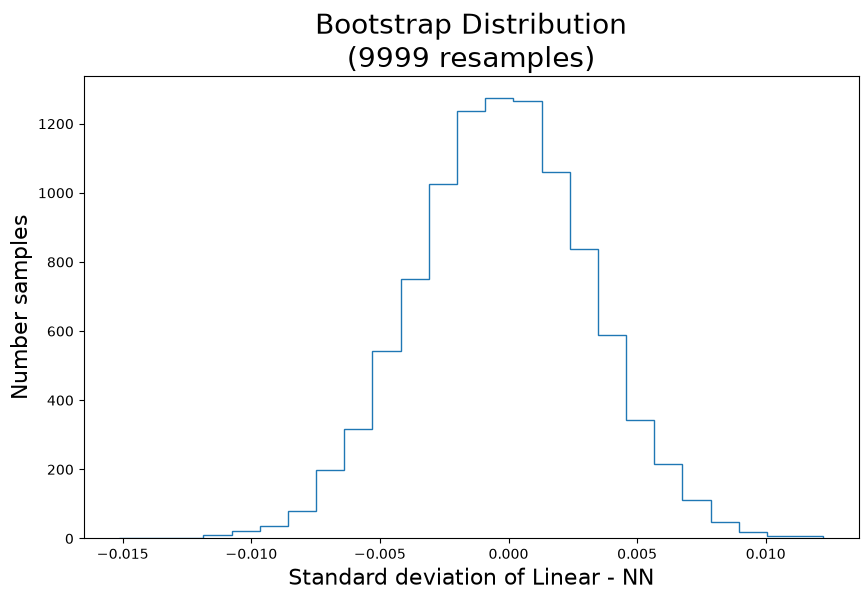

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(bs_diff.bootstrap_distribution, bins=25, histtype='step')
ax.set_title('Bootstrap Distribution\n(9999 resamples)', size=20)
ax.set_xlabel('Standard deviation of Linear - NN', size=16)
ax.set_ylabel('Number samples', size=16)
#ax.legend()

plt.show()

In [ ]:
def mae_difference(y, pred_linear, pred_nn):

    mae_linear = np.mean(np.abs(y - pred_linear))
    mae_nn = np.mean(np.abs(y - pred_nn))

    return mae_linear - mae_nn

In [144]:
bs_diff = ss.bootstrap(
    data=(y_test_true, y_test_linear, y_test_pred),
    statistic=mae_difference,
    paired=True,
    n_resamples=10000,
    confidence_level=.99,
    rng=np.random.default_rng(42)
)

print(f'MAE difference: {mae_difference(y_test_true, y_test_linear, y_test_pred)}')

bs_low, bs_high = bs_diff.confidence_interval.low, bs_diff.confidence_interval.high
print(f'The 99% confidence interval is between {bs_low:.4f} and {bs_high:.4f}')

MAE difference: -0.008193373680114746
The 99% confidence interval is between -0.0161 and -0.0007


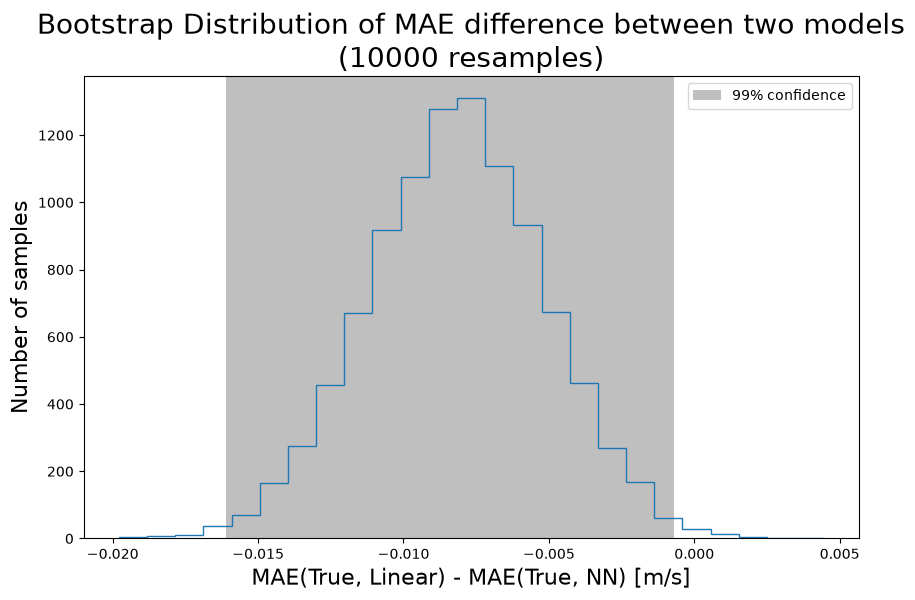

In [149]:
fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(bs_diff.bootstrap_distribution, bins=25, histtype='step')
ax.axvspan(bs_low, bs_high, facecolor='gray', alpha=0.5, label='99% confidence')
ax.set_title('Bootstrap Distribution of MAE difference between two models\n(10000 resamples)', size=20)
ax.set_xlabel('MAE(True, Linear) - MAE(True, NN) [m/s]', size=16)
ax.set_ylabel('Number of samples', size=16)
ax.legend()

plt.show()

99% confidence that the linear model is better than the NN.